In [1]:
#........................Human Activity Recognition Model..................
#Made by Shruti Kumari and Aaliya Bashir 
#Submitted to professor Nipun Batra
from pathlib import Path
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

BASE = Path(r"C:\Users\shrut\OneDrive\Desktop\UCI HAR Dataset")


features = pd.read_csv(BASE / "features.txt", delim_whitespace=True, header=None)
feature_names = features[1].tolist()
unique_feature_names, counts = [], {}
for name in feature_names:
    counts[name] = counts.get(name, 0)
    unique_feature_names.append(f"{name}_{counts[name]}" if counts[name] else name)
    counts[name] += 1


X_train = pd.read_csv(BASE / "train" / "X_train.txt",
                      delim_whitespace=True, header=None, names=unique_feature_names)
y_train = pd.read_csv(BASE / "train" / "y_train.txt", delim_whitespace=True, header=None)

X_test  = pd.read_csv(BASE / "test"  / "X_test.txt",
                      delim_whitespace=True, header=None, names=unique_feature_names)
y_test  = pd.read_csv(BASE / "test"  / "y_test.txt",  delim_whitespace=True, header=None)


activity_labels = pd.read_csv(BASE / "activity_labels.txt",
                              delim_whitespace=True, header=None, index_col=0)
y_train = y_train[0].map(activity_labels[1])
y_test  = y_test[0].map(activity_labels[1])


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_scaled, y_train)

y_pred_test = clf.predict(X_test_scaled)
print("\n UCI‑HAR Test accuracy:", accuracy_score(y_test, y_pred_test))
print("\n Classification report:\n", classification_report(y_test, y_pred_test))
print("\n Confusion matrix:\n", confusion_matrix(y_test, y_pred_test))


C:\Users\shrut\AppData\Local\Temp\ipykernel_23480\513415648.py:13: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  features = pd.read_csv(BASE / "features.txt", delim_whitespace=True, header=None)
C:\Users\shrut\AppData\Local\Temp\ipykernel_23480\513415648.py:22: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv(BASE / "train" / "X_train.txt",
C:\Users\shrut\AppData\Local\Temp\ipykernel_23480\513415648.py:24: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  y_train = pd.read_csv(BASE / "train" / "y_train.txt", delim_whitespace=True, header=None)
C:\Users\shrut\AppData\Local\Temp\ipykernel_23480\513415648.py:26: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated


 UCI‑HAR Test accuracy: 0.9260264675941635

 Classification report:
                     precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       537
           SITTING       0.91      0.89      0.90       491
          STANDING       0.90      0.92      0.91       532
           WALKING       0.89      0.96      0.92       496
WALKING_DOWNSTAIRS       0.97      0.86      0.91       420
  WALKING_UPSTAIRS       0.89      0.90      0.90       471

          accuracy                           0.93      2947
         macro avg       0.93      0.92      0.92      2947
      weighted avg       0.93      0.93      0.93      2947


 Confusion matrix:
 [[537   0   0   0   0   0]
 [  0 439  52   0   0   0]
 [  0  42 490   0   0   0]
 [  0   0   0 476   6  14]
 [  0   0   0  20 361  39]
 [  0   0   0  39   6 426]]


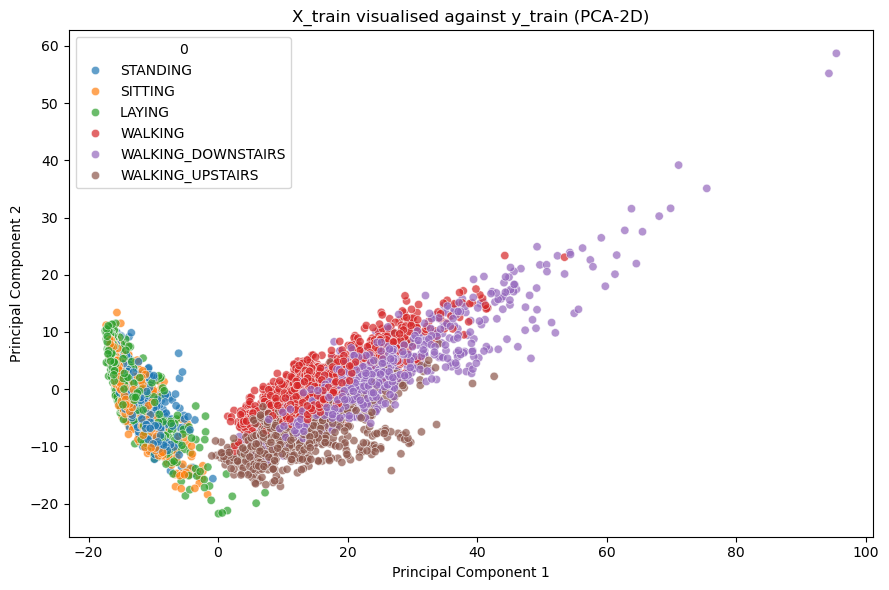

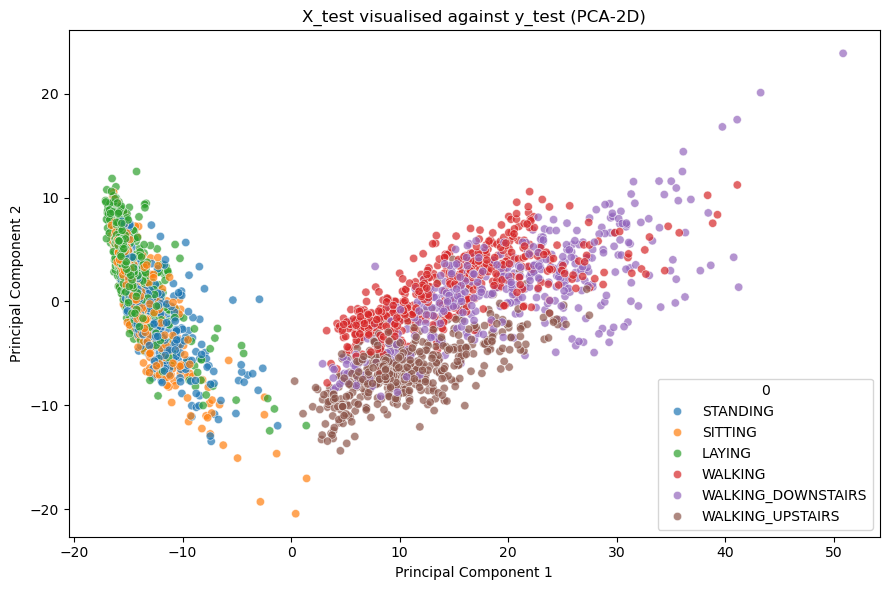

In [2]:


pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

plt.figure(figsize=(9,6))
sns.scatterplot(x=X_train_pca[:,0], y=X_train_pca[:,1], hue=y_train, alpha=0.7, palette="tab10")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("X_train visualised against y_train (PCA‑2D)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,6))
sns.scatterplot(x=X_test_pca[:,0], y=X_test_pca[:,1], hue=y_test, alpha=0.7, palette="tab10")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("X_test visualised against y_test (PCA‑2D)")
plt.tight_layout()
plt.show()


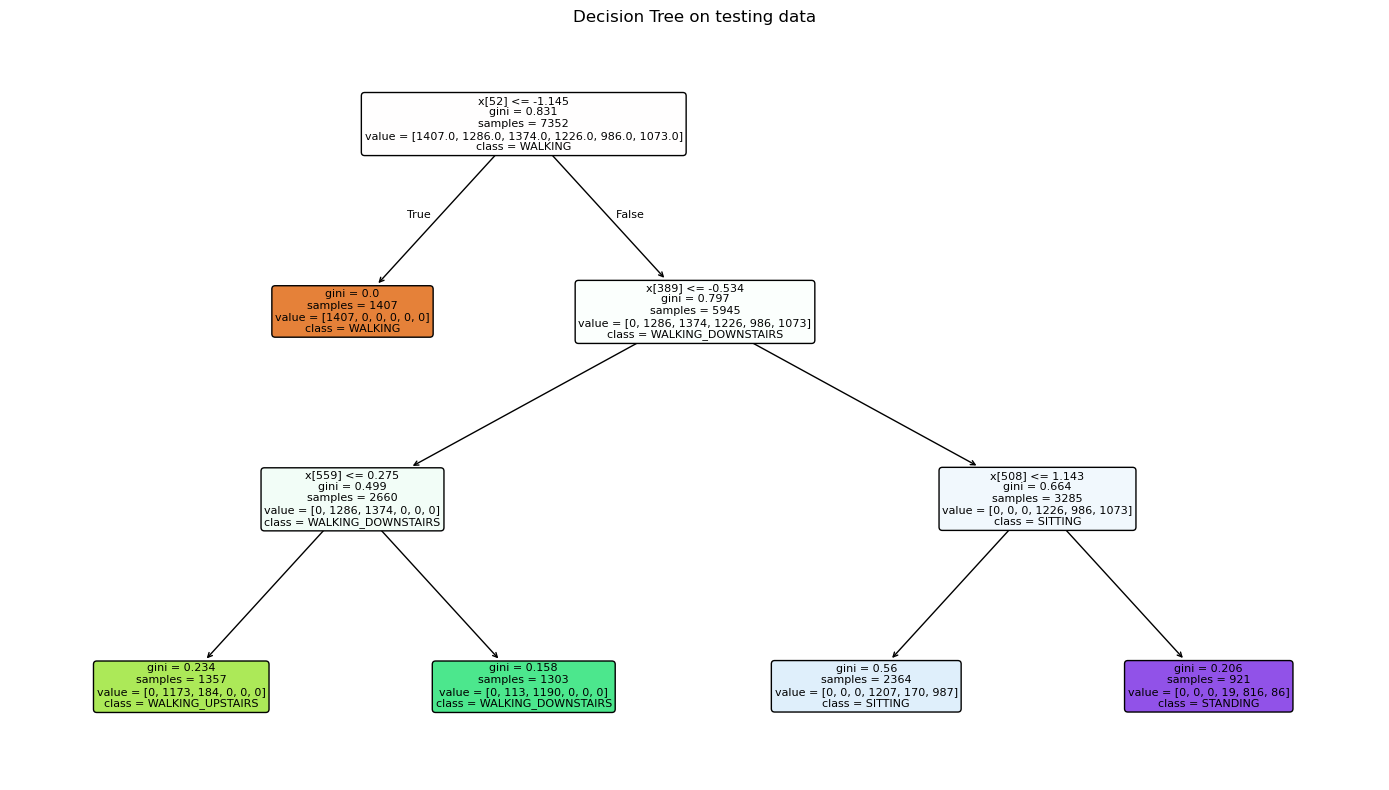

In [3]:
###Nipun batra sir the conclusion we drew from both is that training and testing data has similar patterns
#activities like laying are well separted though its mixing few points like sitting standing and walking types,tese points areoverlapping so the model might 
#get confused in them.

from sklearn.tree import DecisionTreeClassifier, plot_tree


tree_clf = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_clf.fit(X_train_scaled, y_train)

plt.figure(figsize=(14,8))
plot_tree(
    tree_clf,
    feature_names=None,                  
    class_names=activity_labels[1].tolist(),
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree on testing data")
plt.tight_layout()
plt.show()


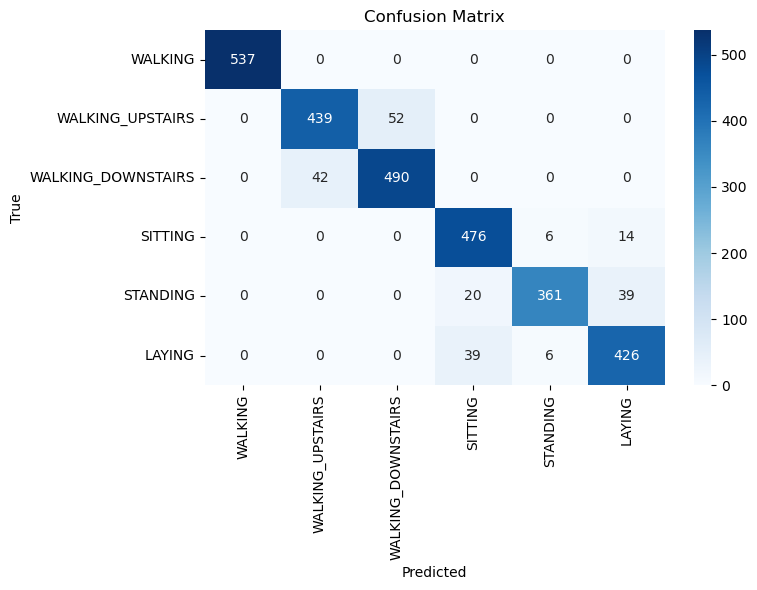

In [4]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=activity_labels[1],
            yticklabels=activity_labels[1])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()



In [7]:

from datetime import timedelta
import numpy as np
from scipy import stats
from scipy import fftpack


PHONE_CSV = Path(r"C:\Users\shrut\OneDrive\Desktop\dataset 1.csv")
WINDOW_SIZE = 128
STEP_SIZE = 64


def load_phone_data(path: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(path, comment="#")
        df = df.select_dtypes(include="number").iloc[:, :4]
    except Exception:
        df = pd.read_csv(path, comment="#", header=None)
        df = df[pd.to_numeric(df[0], errors="coerce").notnull()].iloc[:, :4]

    df.columns = ["time", "ax", "ay", "az"]
    df[["ax", "ay", "az"]] = df[["ax", "ay", "az"]] / 9.80665
    return df


print(f"\nLoading data from: {PHONE_CSV}")
try:
    raw_data = load_phone_data(PHONE_CSV)
    print(f"Loaded {len(raw_data)} samples")
    print("Acceleration range (g):")
    print(f"  X-axis: {raw_data['ax'].min():.2f} → {raw_data['ax'].max():.2f}")
    print(f"  Y-axis: {raw_data['ay'].min():.2f} → {raw_data['ay'].max():.2f}")
    print(f"  Z-axis: {raw_data['az'].min():.2f} → {raw_data['az'].max():.2f}")
except Exception as e:
    print(f"Data loading failed: {e}")
    exit()

raw_data["time"] = pd.to_timedelta(raw_data["time"], unit="s")
raw_data = raw_data.set_index("time").sort_index()

print("\nResampling to 50 Hz …")
resampled = raw_data.resample("20L").mean().interpolate()

if len(resampled) < WINDOW_SIZE:
    print(
        f"\nError: need at least {WINDOW_SIZE} samples "
        f"(2.56 s at 50 Hz); only have {len(resampled)} "
        f"({len(resampled)/50:.2f} s)"
    )
    exit()


def extract_har_features(segment):
    features = []
    x, y, z = segment[:, 0], segment[:, 1], segment[:, 2]

    for axis in (x, y, z):
        features.extend(
            [
                np.mean(axis),
                np.std(axis),
                stats.median_abs_deviation(axis),
                np.max(axis),
                np.min(axis),
                np.mean(np.square(axis)),
            ]
        )

    mag = np.sqrt(x**2 + y**2 + z**2)
    features.extend(
        [
            np.mean(mag),
            np.std(mag),
            np.max(mag),
            np.min(mag),
            np.mean(np.square(mag)),
        ]
    )

    for axis in (x, y, z):
        fft_vals = np.abs(fftpack.fft(axis))[:64] / len(axis)
        features.extend(
            [
                np.mean(fft_vals),
                np.mean(np.square(fft_vals)),
                stats.skew(fft_vals),
                stats.kurtosis(fft_vals),
            ]
        )

    return features


print(f"\nProcessing {len(resampled)} samples into windows …")
segments, timestamps = [], []
for start in range(0, len(resampled) - WINDOW_SIZE + 1, STEP_SIZE):
    segment = resampled.iloc[start : start + WINDOW_SIZE][["ax", "ay", "az"]].values
    segments.append(segment)
    timestamps.append(resampled.index[start])
print(f"{len(segments)} windows created ({WINDOW_SIZE/50:.2f} s each)")

print("\nExtracting features …")
X_phone = pd.DataFrame([extract_har_features(s) for s in segments])

if X_phone.shape[1] != 561:
    
    missing = 561 - X_phone.shape[1]
    X_phone = pd.concat(
        [X_phone, pd.DataFrame(np.zeros((len(segments), missing)))], axis=1
    )

X_phone.columns = unique_feature_names[:561]

print("\nRunning predictions …")
X_phone_scaled = scaler.transform(X_phone)
y_phone_pred = clf.predict(X_phone_scaled)

timeline = pd.DataFrame(
    {
        "window_start": [t.total_seconds() for t in timestamps],
        "window_end": [(t + timedelta(seconds=2.56)).total_seconds() for t in timestamps],
        "activity": y_phone_pred,
    }
)

print("\nPrediction results :")
print(timeline.head(100000))

print("\nActivity distribution:")
print(timeline["activity"].value_counts(normalize=True).to_string())


def get_activity_at(seconds: float) -> str:
    matches = timeline[
        (timeline["window_start"] <= seconds) & (seconds < timeline["window_end"])
    ]
    return matches.iloc[0]["activity"] if not matches.empty else "NO_DATA"


 


Loading data from: C:\Users\shrut\OneDrive\Desktop\dataset 1.csv
Loaded 28793 samples
Acceleration range (g):
  X-axis: -4.72 → 6.93
  Y-axis: -5.33 → 2.46
  Z-axis: -5.84 → 6.92

Resampling to 50 Hz …

Processing 14357 samples into windows …
223 windows created (2.56 s each)

Extracting features …


C:\Users\shrut\AppData\Local\Temp\ipykernel_23480\3255101406.py:41: FutureWarning: 'L' is deprecated and will be removed in a future version, please use 'ms' instead.
  resampled = raw_data.resample("20L").mean().interpolate()



Running predictions …

Prediction results :
     window_start  window_end            activity
0        0.000921    2.560921    WALKING_UPSTAIRS
1        1.280921    3.840921    WALKING_UPSTAIRS
2        2.560921    5.120921    WALKING_UPSTAIRS
3        3.840921    6.400921    WALKING_UPSTAIRS
4        5.120921    7.680921    WALKING_UPSTAIRS
..            ...         ...                 ...
218    279.040921  281.600921  WALKING_DOWNSTAIRS
219    280.320921  282.880921  WALKING_DOWNSTAIRS
220    281.600921  284.160921    WALKING_UPSTAIRS
221    282.880921  285.440921    WALKING_UPSTAIRS
222    284.160921  286.720921    WALKING_UPSTAIRS

[223 rows x 3 columns]

Activity distribution:
activity
WALKING_UPSTAIRS      0.744395
WALKING_DOWNSTAIRS    0.237668
WALKING               0.017937


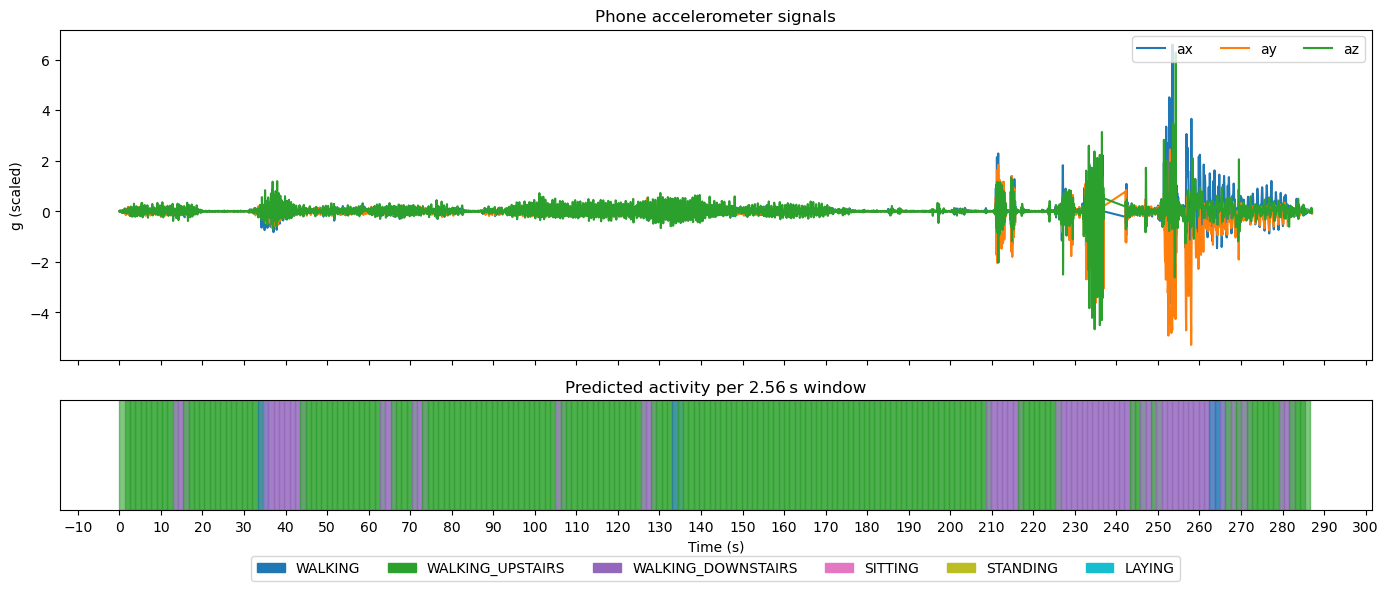

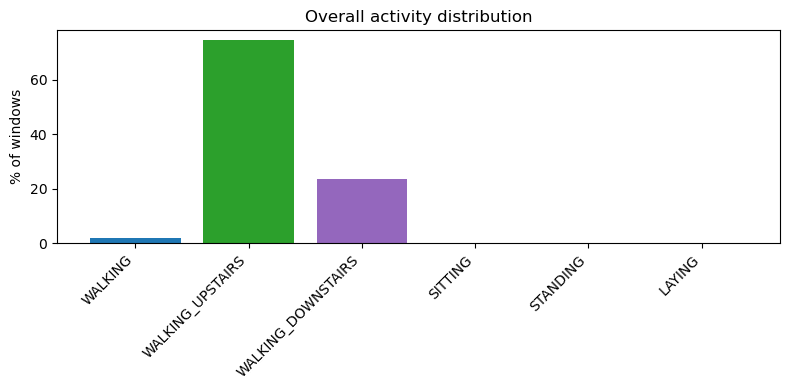

In [6]:
import matplotlib.ticker as mtick
from matplotlib.patches import Patch

activities = activity_labels[1].tolist()
cmap = plt.get_cmap("tab10", len(activities))
act2color = {act: cmap(i) for i, act in enumerate(activities)}

t0 = resampled.index[0]
time_s = (resampled.index - t0).total_seconds().to_numpy()

fig, ax = plt.subplots(2, 1, figsize=(14, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1]})

ax[0].plot(time_s, resampled["ax"], label="ax")
ax[0].plot(time_s, resampled["ay"], label="ay")
ax[0].plot(time_s, resampled["az"], label="az")
ax[0].set_ylabel("g (scaled)")
ax[0].set_title("Phone accelerometer signals")
ax[0].legend(loc="upper right", ncol=3)

for _, row in timeline.iterrows():
    ax[1].axvspan(row["window_start"], row["window_end"], color=act2color[row["activity"]], alpha=0.6)

ax[1].set_ylim(0, 1)
ax[1].set_yticks([])
ax[1].set_xlabel("Time (s)")
ax[1].set_title("Predicted activity per 2.56 s window")
ax[1].xaxis.set_major_locator(mtick.MultipleLocator(10))
ax[1].xaxis.set_major_formatter("{x:.0f}")

handles = [Patch(color=act2color[a], label=a) for a in activities]
ax[1].legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=len(activities))

plt.tight_layout()
plt.show()

dist = timeline["activity"].value_counts(normalize=True).reindex(activities).fillna(0) * 100

plt.figure(figsize=(8, 4))
plt.bar(dist.index, dist.values, color=[act2color[a] for a in dist.index])
plt.ylabel("% of windows")
plt.title("Overall activity distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
